In [63]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
from sklearn import linear_model
from sklearn import model_selection
# from sklearn import metrics
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    r2_score,
    classification_report
)
from sklearn import preprocessing
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
df = pd.read_csv("../data/toxic_comments_with_morph.csv")
df.drop(columns=["Unnamed: 0", "swearing.1"], inplace=True)

In [65]:
df_categorical = df.drop(columns=['comment', 'cleaned_comment', 'comment_without_punct'])

In [66]:
encoder = OneHotEncoder(sparse_output=False)

encoded = encoder.fit_transform(df[['label']])
encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(['label']))
df_categorical = pd.concat([df.drop(columns=['label']), encoded_df], axis=1)
df_categorical = df_categorical.drop(columns=['label_NORMAL', 'comment', 'cleaned_comment', 'comment_without_punct'])

In [68]:
df_binary = df_categorical.drop(columns=['label_INSULT', 'label_OBSCENITY', 'label_THREAT'])

In [70]:
def print_binary_metrics(y_test, y_pred):
    # Вычисление метрик
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_pred)  # или y_pred_proba, если хотите AUC по вероятностям
    r2 = r2_score(y_test, y_pred)

    # Матрица ошибок
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    # Красивый вывод
    print("=" * 50)
    print("📊 РЕЗУЛЬТАТЫ БИНАРНОЙ КЛАССИФИКАЦИИ")
    print("=" * 50)
    print(f"{'Accuracy (Точность):':<25} {accuracy:.4f}")
    print(f"{'Precision (Точность+):':<25} {precision:.4f}")
    print(f"{'Recall (Полнота):':<25} {recall:.4f}")
    print(f"{'F1-Score (F-мера):':<25} {f1:.4f}")
    print(f"{'AUC-ROC:':<25} {auc:.4f}")
    print(f"{"R2: ": <25} {r2:.4f}")
    print("-" * 50)
    print("🧩 Матрица ошибок:")
    print(f"{'':<8} {'Предсказано: 0':<15} {'Предсказано: 1':<15}")
    print(f"{'Факт: 0':<8} {tn:<15} {fp:<15}")
    print(f"{'Факт: 1':<8} {fn:<15} {tp:<15}")
    print("-" * 50)

    # # Дополнительно: подробный отчёт (если нужно)
    # print("📋 Подробный классификационный отчёт:")
    # print(classification_report(y_test, y_pred, target_names=['Класс 0', 'Класс 1']))


In [72]:
X_train, X_test, y_train, y_test = model_selection.train_test_split(df_binary.drop(columns=['is_normal']), df_binary['is_normal'], test_size=0.2, random_state=42)

In [73]:
lr = linear_model.LogisticRegression(max_iter=50000)
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

In [74]:
print_binary_metrics(y_test, y_pred)
# print_binary_metrics(y_test, np.ones(y_test.shape))

📊 РЕЗУЛЬТАТЫ БИНАРНОЙ КЛАССИФИКАЦИИ
Accuracy (Точность):      0.9009
Precision (Точность+):    0.8946
Recall (Полнота):         0.9968
F1-Score (F-мера):        0.9429
AUC-ROC:                  0.7278
R2:                       0.3236
--------------------------------------------------
🧩 Матрица ошибок:
         Предсказано: 0  Предсказано: 1 
Факт: 0  4064            4793           
Факт: 1  129             40671          
--------------------------------------------------


##

<h2>Мультиклассовая классификация (без word2vec)

##

In [75]:
df_multiclass = df_binary.drop(columns=['is_normal'])
df_multiclass['label'] = df['label']

In [82]:
X_train, X_test, y_train, y_test = model_selection.train_test_split(df_multiclass.drop(columns=['label']), df_multiclass['label'], test_size=0.2, random_state=42)

In [83]:
le = preprocessing.LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

In [84]:
lr = linear_model.LogisticRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

/Users/danil/miniforge3/envs/datascience/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [85]:
# r2_score(y_test_enc, y_pred)
print("LR accurcay:", accuracy_score(y_test, y_pred))
print("f1 weighted score:", f1_score(y_test, y_pred, average='weighted'))
print("f1 macro score:", f1_score(y_test, y_pred, average='macro'))
print(classification_report(y_test, y_pred))

LR accurcay: 0.88158769156413
f1 weighted score: 0.8469727104222095
f1 macro score: 0.39572952736960626
              precision    recall  f1-score   support

           0       0.75      0.56      0.64      5645
           1       0.89      1.00      0.94     40800
           2       0.00      0.00      0.00       876
           3       0.08      0.00      0.00      2336

    accuracy                           0.88     49657
   macro avg       0.43      0.39      0.40     49657
weighted avg       0.82      0.88      0.85     49657



<Axes: >

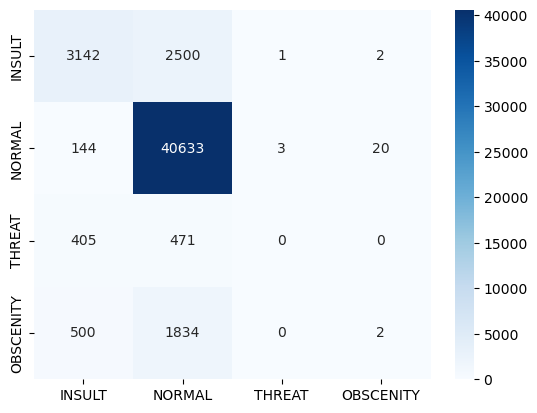

In [86]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test_enc, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=df['label'].unique(), yticklabels=df['label'].unique())


In [87]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [88]:
y_pred_knn = knn.predict(X_test)

print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print("f1 weighted score:", f1_score(y_test, y_pred_knn, average='weighted'))
print("f1 macro score:", f1_score(y_test, y_pred_knn, average='macro'))
print(classification_report(y_test, y_pred_knn))

KNN Accuracy: 0.8475944982580502
f1 weighted score: 0.8056978516046343
f1 macro score: 0.34545191378169776
              precision    recall  f1-score   support

           0       0.65      0.31      0.42      5645
           1       0.86      0.99      0.92     40800
           2       0.17      0.01      0.02       876
           3       0.14      0.01      0.02      2336

    accuracy                           0.85     49657
   macro avg       0.46      0.33      0.35     49657
weighted avg       0.79      0.85      0.81     49657



In [89]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [90]:
y_pred_rf = rf.predict(X_test)

print("RandomForest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("f1 weighted score:", f1_score(y_test, y_pred_rf, average='weighted'))
print("f1 macro score:", f1_score(y_test, y_pred_rf, average='macro'))
print(classification_report(y_test, y_pred_rf))

RandomForest Accuracy: 0.8691221781420545
f1 weighted score: 0.8411639665242737
f1 macro score: 0.4068859731530792
              precision    recall  f1-score   support

           0       0.70      0.53      0.60      5645
           1       0.90      0.98      0.94     40800
           2       0.15      0.03      0.05       876
           3       0.12      0.02      0.04      2336

    accuracy                           0.87     49657
   macro avg       0.47      0.39      0.41     49657
weighted avg       0.82      0.87      0.84     49657



#

<h2> Добавляем word2vec

#

In [91]:
# выше - результаты без токенизации

# добавим токенизацию и word2vec

In [92]:
cleaned_comms = df['cleaned_comment'].replace(np.nan, '', regex=True).tolist()
def preprocess(text):
    if isinstance(text, str):
        text = text.lower()
        text = text.split()
    else: 
        text = []
    return text
comments = [preprocess(com) for com in cleaned_comms]

In [ ]:
from gensim.models import Word2Vec
from tqdm import tqdm
from gensim.models import KeyedVectors

# Тренировка собственной модели Word2Vec
w2v = Word2Vec(vector_size=300, window=5, min_count=2, workers=4)
w2v.build_vocab(comments)
for epoch in tqdm(range(10)):
    w2v.train(comments, total_examples=w2v.corpus_count, epochs=1)

 20%|██        | 2/10 [00:04<00:18,  2.28s/it]Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
100%|██████████| 10/10 [00:18<00:00,  1.85s/it]


In [ ]:
# Использование предобученной модели Word2Vec

w2v_cc = KeyedVectors.load_word2vec_format("data/models/cc.ru.300.bin", binary=True, encoding='latin1')

ValueError: invalid literal for int() with base 10: 'º\x16O/'

In [94]:
def vectorize(text, model):
    words = preprocess(text)
    vectors = [model[w] for w in words if w in model]
    if not vectors:
        return np.zeros(model.vector_size)
    return np.mean(vectors, axis=0)

In [95]:
comment_vectors = [vectorize(x, w2v.wv) for x in df['cleaned_comment']]
comment_vectors = np.stack(np.array(comment_vectors))

In [96]:
df_multiclass_vectors = df_multiclass.copy()
for i in range(comment_vectors.shape[1]):
    df_multiclass_vectors[f"w2v_{i}"] = comment_vectors[:, i]

/var/folders/4p/4cl76w7n2wd8f5rtvp0y4zb00000gn/T/ipykernel_46301/2153711281.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_multiclass_vectors[f"w2v_{i}"] = comment_vectors[:, i]
/var/folders/4p/4cl76w7n2wd8f5rtvp0y4zb00000gn/T/ipykernel_46301/2153711281.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_multiclass_vectors[f"w2v_{i}"] = comment_vectors[:, i]
/var/folders/4p/4cl76w7n2wd8f5rtvp0y4zb00000gn/T/ipykernel_46301/2153711281.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result 

In [97]:
df_multiclass_vectors

,length_sym,length_words,av_word_len,swearing,has_positive_emoji,has_negative_emoji,has_obscene_emoji,imperative,2nd_prsn_count,3nd_prsn_count,...,w2v_290,w2v_291,w2v_292,w2v_293,w2v_294,w2v_295,w2v_296,w2v_297,w2v_298,w2v_299
0,20,3,5.666667,False,False,False,False,False,0,0,...,0.010776,0.593297,0.661184,0.222967,0.474794,0.596054,0.193392,-0.947734,0.259751,-0.007230
1,180,28,5.214286,False,False,False,False,False,0,0,...,0.022850,0.215770,0.076367,0.023507,0.191531,0.169628,0.006152,-0.132915,0.277936,-0.051598
2,379,54,5.777778,False,False,False,False,False,0,0,...,-0.052349,0.312360,0.380998,-0.115904,0.226410,0.376889,-0.077828,-0.155238,0.244739,-0.026116
3,72,10,5.700000,False,False,False,False,False,0,0,...,0.025070,0.241639,0.287219,-0.112679,0.091095,0.249259,-0.187731,-0.252892,0.321163,-0.091848
4,39,6,5.500000,False,False,False,False,False,0,0,...,0.159265,1.039039,0.853442,-0.221889,0.289292,0.437053,0.124203,0.210159,0.130875,-0.189058
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
248276,28,4,4.500000,False,False,False,False,False,0,0,...,0.695819,0.729913,0.870601,0.265074,-0.174474,1.043338,-0.344287,-0.432356,0.278190,-0.916604
248277,143,23,5.260870,True,False,False,False,False,2,0,...,0.029465,0.224935,0.165419,0.048412,0.135992,0.069806,0.154637,-0.023791,0.117761,-0.058250
248278,188,30,4.833333,False,False,False,False,False,0,1,...,0.134241,0.454287,0.371048,-0.072814,0.120312,0.384420,-0.193419,-0.037993,0.105324,-0.002168
248279,21,3,6.000000,False,False,False,False,False,0,0,...,0.817961,-0.747060,0.025021,-0.230732,-0.640559,-1.325133,-0.502434,-0.144841,1.347593,0.633920


In [98]:
X_train, X_test, y_train, y_test = model_selection.train_test_split(df_multiclass_vectors.drop(columns=['label']), 
                                                                    df_multiclass_vectors['label'], test_size=0.2, random_state=42)
le = preprocessing.LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

In [99]:
standard_scaler = preprocessing.StandardScaler()
X_train = standard_scaler.fit_transform(X_train)
X_test = standard_scaler.transform(X_test)

In [100]:
lr = linear_model.LogisticRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

/Users/danil/miniforge3/envs/datascience/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [101]:
print("LR accurcay:", accuracy_score(y_test, y_pred))
print("f1 weighted score:", f1_score(y_test, y_pred, average='weighted'))
print("f1 macro score:", f1_score(y_test, y_pred, average='macro'))
print(classification_report(y_test, y_pred))

LR accurcay: 0.9225486839720483
f1 weighted score: 0.9158271572827642
f1 macro score: 0.680951123819084
              precision    recall  f1-score   support

           0       0.78      0.70      0.74      5645
           1       0.95      0.99      0.97     40800
           2       0.67      0.24      0.35       876
           3       0.80      0.58      0.67      2336

    accuracy                           0.92     49657
   macro avg       0.80      0.63      0.68     49657
weighted avg       0.92      0.92      0.92     49657



<Axes: >

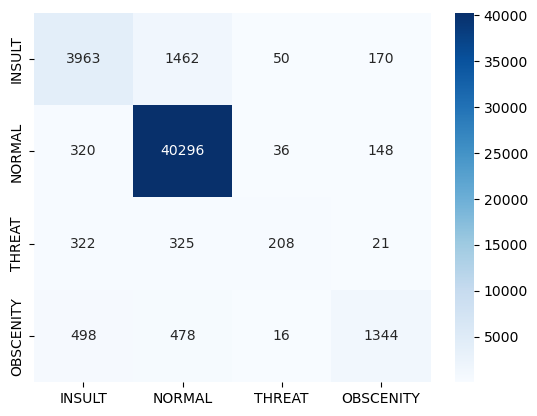

In [102]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=df['label'].unique(), yticklabels=df['label'].unique())

In [103]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [104]:
y_pred_knn = knn.predict(X_test)

print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print("f1 weighted score:", f1_score(y_test, y_pred_knn, average='weighted'))
print("f1 macro score:", f1_score(y_test, y_pred_knn, average='macro'))
print(classification_report(y_test, y_pred_knn))

KNN Accuracy: 0.9098616509253479
f1 weighted score: 0.9021115332640918
f1 macro score: 0.6596968773649108
              precision    recall  f1-score   support

           0       0.73      0.62      0.67      5645
           1       0.94      0.98      0.96     40800
           2       0.63      0.25      0.36       876
           3       0.79      0.55      0.65      2336

    accuracy                           0.91     49657
   macro avg       0.77      0.60      0.66     49657
weighted avg       0.90      0.91      0.90     49657



In [105]:
# svm = SVC(kernel='linear', C=1.0, gamma='scale')
# svm.fit(X_train, y_train)

In [106]:
# y_pred_svm = svm.predict(X_test)

# print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
# print(classification_report(y_test, y_pred_svm))

In [108]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [109]:
y_pred_rf = rf.predict(X_test)

print("RandomForest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("f1 weighted score:", f1_score(y_test, y_pred_rf, average='weighted'))
print("f1 macro score:", f1_score(y_test, y_pred_rf, average='macro'))
print(classification_report(y_test, y_pred_rf))


RandomForest Accuracy: 0.9243208409690477
f1 weighted score: 0.9166146618086974
f1 macro score: 0.6737726163730869
              precision    recall  f1-score   support

           0       0.78      0.70      0.74      5645
           1       0.95      0.99      0.97     40800
           2       0.76      0.20      0.32       876
           3       0.82      0.56      0.67      2336

    accuracy                           0.92     49657
   macro avg       0.83      0.61      0.67     49657
weighted avg       0.92      0.92      0.92     49657

